In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Add Split Logic
---
## Preprocessing Should Happen for both training and test datasets

In [ ]:
df = pd.read_csv('training_data.csv')
df.head()


In [62]:
df.isnull().sum()

Unnamed: 0                      0
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               86780
A1Cresult                   76267
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [ ]:
"""
Imputing with NaN to get True NaN missing value counts

"""
missing_cols = ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'gender']

column_to_missing = {}
for col in missing_cols:
    if col != 'gender':
        column_to_missing[col] = '?'
    else:
        column_to_missing[col] = 'Unknown/Invalid'

print(column_to_missing)

{'race': '?', 'weight': '?', 'payer_code': '?', 'medical_specialty': '?', 'diag_1': '?', 'diag_2': '?', 'diag_3': '?', 'gender': 'Unknown/Invalid'}


In [ ]:
df_1 = df.copy()
for col, miss_val in column_to_missing.items():
    df_1[col] = df_1[col].replace(miss_val, np.nan)
message = "True Missing Counts:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().sum()

True Missing Counts:
True Missing Counts:


Unnamed: 0                      0
encounter_id                    0
patient_nbr                     0
race                         2044
gender                          2
age                             0
weight                      88727
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  36237
medical_specialty           44911
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         19
diag_2                        332
diag_3                       1292
number_diagnoses                0
max_glu_serum               86780
A1Cresult                   76267
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride   

In [65]:
message = "Percentage of Missing Values:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().mean().round(4)*100

Percentage of Missing Values:


Unnamed: 0                   0.00
encounter_id                 0.00
patient_nbr                  0.00
race                         2.23
gender                       0.00
age                          0.00
weight                      96.88
admission_type_id            0.00
discharge_disposition_id     0.00
admission_source_id          0.00
time_in_hospital             0.00
payer_code                  39.56
medical_specialty           49.04
num_lab_procedures           0.00
num_procedures               0.00
num_medications              0.00
number_outpatient            0.00
number_emergency             0.00
number_inpatient             0.00
diag_1                       0.02
diag_2                       0.36
diag_3                       1.41
number_diagnoses             0.00
max_glu_serum               94.75
A1Cresult                   83.27
metformin                    0.00
repaglinide                  0.00
nateglinide                  0.00
chlorpropamide               0.00
glimepiride   

In [66]:
df_1_non_numeric = df_1.select_dtypes(exclude='number')
for col in df_1_non_numeric.columns.values:
    print(f"{col}: ", df_1[col].unique(), end='\n\n')

race:  ['Caucasian' 'AfricanAmerican' 'Hispanic' nan 'Other' 'Asian']

gender:  ['Female' 'Male' nan]

age:  ['[60-70)' '[40-50)' '[70-80)' '[80-90)' '[50-60)' '[30-40)' '[20-30)'
 '[90-100)' '[10-20)' '[0-10)']

weight:  [nan '[75-100)' '[100-125)' '[50-75)' '[125-150)' '[25-50)' '[0-25)'
 '[150-175)' '[175-200)' '>200']

payer_code:  ['MC' nan 'BC' 'CM' 'SP' 'HM' 'OG' 'MD' 'UN' 'CP' 'OT' 'PO' 'DM' 'WC' 'SI'
 'CH' 'MP' 'FR']

medical_specialty:  [nan 'Family/GeneralPractice' 'InternalMedicine' 'Cardiology'
 'Surgery-General' 'Surgery-Vascular' 'Urology' 'Emergency/Trauma'
 'Surgery-Neuro' 'Orthopedics-Reconstructive'
 'PhysicalMedicineandRehabilitation' 'Surgery-Cardiovascular/Thoracic'
 'ObstetricsandGynecology' 'Gastroenterology' 'Orthopedics'
 'Surgery-Plastic' 'Podiatry' 'Surgery-Thoracic' 'Nephrology' 'Psychiatry'
 'Radiologist' 'Pulmonology' 'Pediatrics-CriticalCare' 'Psychology'
 'Pediatrics-Endocrinology' 'Neurology' 'Hematology/Oncology' 'Pediatrics'
 'OutreachServices' 'Surg

In [67]:
"""
Diagnosis Groups:

Grouping based on ICD9 Grouping (source: Wikipedia)
"""
diags_ICD9_dict = {
    '001–139': 'infectious and parasitic diseases',
    '140–239': 'neoplasms',
    '240–279': 'endocrine, nutritional and metabolic diseases, and immunity disorders',
    '280–289': 'diseases of the blood and blood-forming organs',
    '290–319': 'mental disorders',
    '320–389': 'diseases of the nervous system and sense organs',
    '390–459': 'diseases of the circulatory system',
    '460–519': 'diseases of the respiratory system',
    '520–579': 'diseases of the digestive system',
    '580–629': 'diseases of the genitourinary system',
    '630–679': 'complications of pregnancy, childbirth, and the puerperium',
    '680–709': 'diseases of the skin and subcutaneous tissue',
    '710–739': 'diseases of the musculoskeletal system and connective tissue',
    '740–759': 'congenital anomalies',
    '760–779': 'certain conditions originating in the perinatal period',
    '780–799': 'symptoms, signs, and ill-defined conditions',
    '800–999': 'injury and poisoning',
    'E & V codes': 'external causes of injury and supplemental classification',
}

def categorize_diag(code: str) -> str:
    code_float = float(code)
    code_int = int(code_float)
    if code_int >= 800:
        return '800–999'
    elif code_int >= 780:
        return '780–799'
    elif code_int >= 760:
        return '760–779'
    elif code_int >= 740:
        return '740–759'
    elif code_int >= 710:
        return '710–739'
    elif code_int >= 680:
        return '680–709'
    elif code_int >= 630:
        return '630–679'
    elif code_int >= 580:
        return '580–629'
    elif code_int >= 520:
        return '520–579'
    elif code_int >= 460:
        return '460–519'
    elif code_int >= 390:
        return '390–459'
    elif code_int >= 320:
        return '320–389'
    elif code_int >= 290:
        return '290–319'
    elif code_int >= 280:
        return '280–289'
    elif code_int >= 240:
        return '240–279'
    elif code_int >= 140:
        return '140–239'
    else:
        return '001–139'

def convert_EV_code(code: str) -> str:
    return 'E & V codes'


"""
Medical Specialty Groups:

Grouping based on Google Gemini output
"""

specialty_mapping = {
    'PrimaryCare': [
        'Family/GeneralPractice', 'InternalMedicine', 'Hospitalist', 
        'Osteopath', 'Resident'
    ],
    'Surgery': [
        'Surgery-General', 'Surgery-Vascular', 'Urology', 'Surgery-Neuro', 
        'Orthopedics-Reconstructive', 'Surgery-Cardiovascular/Thoracic', 
        'Orthopedics', 'Surgery-Plastic', 'Podiatry', 'Surgery-Thoracic', 
        'Surgery-Colon&Rectal', 'Otolaryngology', 'Surgery-Cardiovascular', 
        'Surgeon', 'Proctology', 'Surgery-Maxillofacial', 'SurgicalSpecialty', 
        'Dentistry', 'Ophthalmology', 'Surgery-PlasticwithinHeadandNeck'
    ],
    'InternalMedicine_Subspecialty': [
        'Cardiology', 'Gastroenterology', 'Nephrology', 'Pulmonology', 
        'Neurology', 'Hematology/Oncology', 'Endocrinology-Metabolism', 
        'Hematology', 'Oncology', 'Endocrinology', 'InfectiousDiseases', 
        'Rheumatology', 'AllergyandImmunology', 'Neurophysiology', 'Dermatology'
    ],
    'Emergency_CriticalCare': [
        'Emergency/Trauma'
    ],
    'Maternal_Pediatric': [
        'ObstetricsandGynecology', 'Pediatrics-CriticalCare', 'Pediatrics-Endocrinology', 
        'Pediatrics', 'Gynecology', 'Pediatrics-Pulmonology', 'Pediatrics-Neurology', 
        'Obsterics&Gynecology-GynecologicOnco', 'Pediatrics-AllergyandImmunology', 
        'Cardiology-Pediatric', 'Anesthesiology-Pediatric', 'Obstetrics', 
        'Surgery-Pediatric', 'Perinatology', 'Pediatrics-EmergencyMedicine', 
        'Pediatrics-Hematology-Oncology', 'Psychiatry-Child/Adolescent', 
        'Pediatrics-InfectiousDiseases'
    ],
    'Psych_Rehab_Support': [
        'PhysicalMedicineandRehabilitation', 'Psychiatry', 'Psychology', 
        'Anesthesiology', 'Speech', 'SportsMedicine'
    ],
    'Diagnostics_Other': [
        'Radiologist', 'Radiology', 'Pathology', 'OutreachServices', 'DCPTEAM'
    ],
    'Missing': [
        'PhysicianNotFound'
    ]
}

def map_specialty_to_group(specialty):
    if pd.isna(specialty):
        return specialty
    for key, value in specialty_mapping.items():
        if specialty in value:
            return key
    return 'Other'

def build_map_to_none(categories : list[int]):
    def map_to_one(category):
        if category in categories:
            return np.nan
        return category
    return map_to_one

---
## Starting Feature Transformations & Imputation

In [72]:
"""
Grouping Transformations (4 total)

2 types: diagnosis and medical specialty
"""

"""
Categorizing diagnoses codes into diagnosis groups => reduces features.

Applies to: `diag_1`, `diag_2`, & `diag_3`
"""
df_2 = df_1.copy()
for i in range(1,4):

    mask = df_2[f'diag_{i}'].str.contains('^[EV]', regex=True, na=False)
    mask_nan = df_2[f'diag_{i}'].isna()
    combined_mask = mask | mask_nan
    
    df_2.loc[~combined_mask, f'diag_{i}'] = df_2.loc[~combined_mask, f'diag_{i}'].apply(categorize_diag)
    df_2.loc[mask, f'diag_{i}'] = df_2.loc[mask, f'diag_{i}'].apply(convert_EV_code)
    print(f"diag_{i}: ", df_2[f'diag_{i}'].unique(), end='\n\n')

"""
Based on medical specialty => reduces total features

Applies to: `medical_specialty`
"""
df_2['medical_specialty'] = df_2['medical_specialty'].apply(map_specialty_to_group)
print("medical_specialty: ", df_2['medical_specialty'].unique(), end = "\n\n")

"""
Categorizing ambiguous mappings together.

For example, admission_source_id has categories 9, 15, 17, 20, and 21, which map to
Not availble, not availible, Null, not mapped, unknown

Group 9, 15, 17, 20 and 21 together to null. Reduces features & remove noise

Applies to `admission_type_id`, `discharge_disposition_id`, `admission_source_id`
"""
df_2['admission_type_id'] = df_2['admission_type_id'].apply(build_map_to_none([5, 6, 8]))
df_2['discharge_disposition_id'] = df_2['discharge_disposition_id'].apply(build_map_to_none([18, 25, 26]))
df_2['admission_source_id'] = df_2['admission_source_id'].apply(build_map_to_none([9, 15, 17, 20, 21]))

print("admission_type_id: ", np.sort(df_2['admission_type_id'].unique()), end = "\n\n")
print("discharge_disposition_id: ", np.sort(df_2['discharge_disposition_id'].unique()), end = "\n\n")
print("admission_source_id: ", np.sort(df_2['admission_source_id'].unique()), end = "\n\n")

diag_1:  ['460–519' '390–459' '520–579' '710–739' '800–999' '780–799' '290–319'
 '140–239' '240–279' '580–629' '001–139' 'E & V codes' '630–679' '680–709'
 '280–289' '320–389' nan '740–759']

diag_2:  ['390–459' '240–279' '280–289' '580–629' 'E & V codes' '780–799' '460–519'
 '320–389' '520–579' '290–319' '680–709' '001–139' '800–999' '710–739'
 '140–239' '630–679' nan '740–759']

diag_3:  ['520–579' '290–319' '580–629' '680–709' '390–459' '240–279' 'E & V codes'
 '001–139' '460–519' '320–389' '280–289' '780–799' '630–679' '800–999'
 '710–739' nan '740–759' '140–239']

medical_specialty:  [nan 'PrimaryCare' 'InternalMedicine_Subspecialty' 'Surgery'
 'Emergency_CriticalCare' 'Psych_Rehab_Support' 'Maternal_Pediatric'
 'Diagnostics_Other' 'Missing']

admission_type_id:  [ 1.  2.  3.  4.  7. nan]

discharge_disposition_id:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 19.
 20. 22. 23. 24. 27. 28. nan]

admission_source_id:  [ 1.  2.  3.  4.  5.  6.  7.  8. 10. 11. 

In [ ]:
"""
Feature Drops:

Reasoning: 
- feature has missing 90+% of values (weight)
- feature only consists of 1 unique value
"""
df_3 = df_2.copy()
df_3.drop(columns=['weight', 'examide', 'citoglipton'], inplace=True)
print("Shape BEFORE drops: ", df_2.shape)
print("Shape AFTER drops: ", df_3.shape)

Shape BEFORE drops:  (91589, 51)
Shape AFTER drops:  (91589, 48)


In [ ]:
"""
Mode Imputation
"""
df_4 = df_3.copy()
mode_impute_col_names = ['race', 'payer_code', 'medical_specialty', 'gender', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

def mode_impute(df_column):
    mask = df_column.notna()
    mode = df_column[mask].mode()[0]
    print(f"Mode:\t\t", mode)
    updated_df_column = df_column.fillna(mode)
    return updated_df_column

for name in mode_impute_col_names:
    print(name, end=' ')
    df_4[name] = mode_impute(df_4[name])

race Mode:		 Caucasian
payer_code Mode:		 MC
medical_specialty Mode:		 PrimaryCare
gender Mode:		 Female
diag_1 Mode:		 390–459
diag_2 Mode:		 390–459
diag_3 Mode:		 390–459
admission_type_id Mode:		 1.0
discharge_disposition_id Mode:		 1.0
admission_source_id Mode:		 7.0


In [ ]:
message = "Before Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_3[mode_impute_col_names].isnull().sum()

Before Mode Impute:


race                         2044
payer_code                  36237
medical_specialty           44911
gender                          2
diag_1                         19
diag_2                        332
diag_3                       1292
admission_type_id            9319
discharge_disposition_id     4207
admission_source_id          6358
dtype: int64

In [ ]:
message = "After Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_4[mode_impute_col_names].isnull().sum()

After Mode Impute:


race                        0
payer_code                  0
medical_specialty           0
gender                      0
diag_1                      0
diag_2                      0
diag_3                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
dtype: int64

In [ ]:
"""
NaN Replacement:

Treating Unknown as a possible valid value.

Applies to: 'max_glu_serum', 'A1Cresult'

Based on potential significance of these values missing.
"""
df_5 = df_4.copy()
col_names = ['max_glu_serum', 'A1Cresult']

for name in col_names:
    df_5[name] = df_5[name].replace(np.nan, 'Unknown')

In [ ]:
message = "After ALL Transformations and Imputes:"
print(message, '\n', '='*len(message), sep='')
df_5.isna().sum()

After ALL Transformations and Imputes:


Unnamed: 0                  0
encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

## Done with Imputations and Transformations
---
## Starting Encoding
### **NOTE**: Use `df_5` from this point onwards.

In [ ]:
df_5_non_numeric = df_5.select_dtypes(exclude='number')

categorical_columns = list(df_5_non_numeric.columns.values)
categorical_columns += ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

non_ordinal_cols = [categorical_columns[0]] + categorical_columns[3:8] + categorical_columns[33:]
ordinal_cols = categorical_columns[1:3] + categorical_columns[8:33]

print("categorical_columns: ", categorical_columns, end='\n\n')
print("Non Ordinal: ", non_ordinal_cols, end='\n\n')
print("Ordinal: ", ordinal_cols)

categorical_columns:  ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Non Ordinal:  ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'readmitted', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Ordinal:  ['gender', 'age', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'ro

In [ ]:
"""
Define Orderings for every ordinal column
"""

quad_med = ['Down', 'No', 'Steady', 'Up']
binary_med = ['No', 'Steady']

mapping = {
    # Custom/Unique orderings
    'gender': ['Male', 'Female'],
    'age': ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'],
    'weight': ['[0-25)', '[25-50)', '[50-75)', '[75-100)', '[100-125)', '[125-150)', '[150-175)', '[175-200)', '>200'],
    'max_glu_serum': ['Unknown', 'Norm', '>200', '>300'],
    'A1Cresult': ['Unknown', 'Norm', '>7', '>8'],
    'change': ['No', 'Ch'],
    'diabetesMed': ['No', 'Yes'],
    'readmitted': ['NO', '>30', '<30'],
    
    # 3-level medication (Unique)
    'tolazamide': ['No', 'Steady', 'Up'],
    
    # 4-level medications (Repeated)
    'metformin': quad_med,
    'repaglinide': quad_med,
    'nateglinide': quad_med,
    'chlorpropamide': quad_med,
    'glimepiride': quad_med,
    'glipizide': quad_med,
    'glyburide': quad_med,
    'pioglitazone': quad_med,
    'rosiglitazone': quad_med,
    'acarbose': quad_med,
    'miglitol': quad_med,
    'insulin': quad_med,
    'glyburide-metformin': quad_med,
    
    # 2-level medications (Repeated)
    'acetohexamide': binary_med,
    'tolbutamide': binary_med,
    'troglitazone': binary_med,
    'glipizide-metformin': binary_med,
    'glimepiride-pioglitazone': binary_med,
    'metformin-rosiglitazone': binary_med,
    'metformin-pioglitazone': binary_med
}

In [ ]:
"""
Performing Encodings:

First starting with Ordinal Encoding

Second doing the Non-ordinal (OneHot) Encoding
"""

df_6 = df_5.copy()

# Ordinal Encoding
for col in ordinal_cols:
    ord_enc = OrdinalEncoder(categories=[mapping[col]])
    df_6[col] = ord_enc.fit_transform(df_6[[col]])

# Non-Ordinal, One-Hot Encoding
df_6 = pd.get_dummies(df_6, columns=non_ordinal_cols, drop_first=True)

In [ ]:
df_6.head()

,Unnamed: 0,encounter_id,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,race_Asian,race_Caucasian,race_Hispanic,race_Other,payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Emergency_CriticalCare,medical_specialty_InternalMedicine_Subspecialty,medical_specialty_Maternal_Pediatric,medical_specialty_Missing,medical_specialty_PrimaryCare,medical_specialty_Psych_Rehab_Support,medical_specialty_Surgery,diag_1_140–239,diag_1_240–279,diag_1_280–289,diag_1_290–319,diag_1_320–389,diag_1_390–459,diag_1_460–519,diag_1_520–579,diag_1_580–629,diag_1_630–679,diag_1_680–709,diag_1_710–739,diag_1_740–759,diag_1_780–799,diag_1_800–999,diag_1_E & V codes,diag_2_140–239,diag_2_240–279,diag_2_280–289,diag_2_290–319,diag_2_320–389,diag_2_390–459,diag_2_460–519,diag_2_520–579,diag_2_580–629,diag_2_630–679,diag_2_680–709,diag_2_710–739,diag_2_740–759,diag_2_780–799,diag_2_800–999,diag_2_E & V codes,diag_3_140–239,diag_3_240–279,diag_3_280–289,diag_3_290–319,diag_3_320–389,diag_3_390–459,diag_3_460–519,diag_3_520–579,diag_3_580–629,diag_3_630–679,diag_3_680–709,diag_3_710–739,diag_3_740–759,diag_3_780–799,diag_3_800–999,diag_3_E & V codes,readmitted_>30,readmitted_NO,admission_type_id_2.0,admission_type_id_3.0,admission_type_id_4.0,admission_type_id_7.0,discharge_disposition_id_2.0,discharge_disposition_id_3.0,discharge_disposition_id_4.0,discharge_disposition_id_5.0,discharge_disposition_id_6.0,discharge_disposition_id_7.0,discharge_disposition_id_8.0,discharge_disposition_id_9.0,discharge_disposition_id_10.0,discharge_disposition_id_11.0,discharge_disposition_id_12.0,discharge_disposition_id_13.0,discharge_disposition_id_14.0,discharge_disposition_id_15.0,discharge_disposition_id_16.0,discharge_disposition_id_17.0,discharge_disposition_id_19.0,discharge_disposition_id_20.0,discharge_disposition_id_22.0,discharge_disposition_id_23.0,discharge_disposition_id_24.0,discharge_disposition_id_27.0,discharge_disposition_id_28.0,admission_source_id_2.0,admission_source_id_3.0,admission_source_id_4.0,admission_source_id_5.0,admission_source_id_6.0,admission_source_id_7.0,admission_source_id_8.0,admission_source_id_10.0,admission_source_id_11.0,admission_source_id_13.0,admission_source_id_14.0,admission_source_id_22.0,admission_source_id_25.0
0,0,259912530,88114716,1.0,6.0,1,34,0,10,6,0,0,9,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,1,37094196,604017,1.0,6.0,2,39,0,11,0,0,0,4,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,F

In [ ]:
# Since our readmitted columns is split into 2, readmitted_>30	readmitted_NO
# A quick fix would just be to reconstruct it

# Reconstruct readmitted column
df_6['readmitted'] = np.select(
    [
        df_6['readmitted_NO'] == True,
        df_6['readmitted_>30'] == False
    ],
    [
        'NO',
        '>30'
    ],
    default='<30'
)

# Drop the extra columns created from encoding
df_6 = df_6.drop(columns=["readmitted_NO", "readmitted_>30"])

In [ ]:
df_6.shape

(91589, 154)

## End of Encodings
---
### **NOTE**: Please use `df_6` from here on out.
---
## Start of EDA - Exploratory Data Analysis

<Axes: >

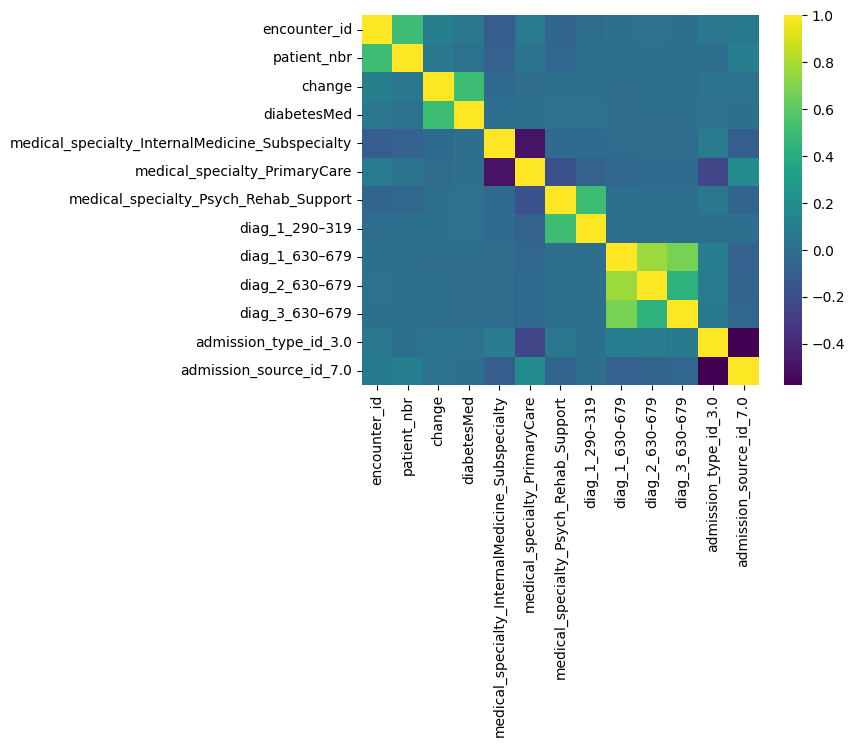

In [ ]:
min_thresh = 0.5
corr_matrix = df_6.corr(numeric_only=True)
high_corr_features = corr_matrix.index[(abs(corr_matrix) >= min_thresh).sum() > 1]
high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
sns.heatmap(high_corr_matrix, cmap='viridis')

In [ ]:
"""
Skew Analysis
"""
# Skewness Thresholds
upper_bound, lower_bound = 0.5, -0.5

all_cols = df_6.columns
encoded_cols = set(df_6.filter(regex=rf"^({'|'.join(categorical_columns)})_").columns)
non_encoded_cols = [c for c in all_cols if c not in encoded_cols]

non_encoded_skews = []
for col in sorted(non_encoded_cols):
    if pd.api.types.is_numeric_dtype(df_6[col]):
        skewness = df_6[col].skew()
        if skewness > upper_bound or skewness < lower_bound:
            non_encoded_skews.append((col,skewness))

encoded_skews = []
for category in categorical_columns:
    cols = df_6.filter(regex=rf'^{category}_').columns
    if not cols.empty:
        series = df_6[cols].values.argmax(axis=1)
        group_skew = pd.Series(series).skew()
        if group_skew > upper_bound or group_skew < lower_bound:
            encoded_skews.append((category, group_skew))

non_encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))
encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))

message = "Skewed Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in non_encoded_skews:
    print(f"{col:30} Skew: {skew:.4f}")

message = "\nSkewed Non-Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in encoded_skews:
    print(f"Grouped {col:22} Skew: {skew:.4f}")

Skewed Ordinal Columns:
acetohexamide                  Skew: 302.6367
glimepiride-pioglitazone       Skew: 302.6367
metformin-pioglitazone         Skew: 302.6367
metformin-rosiglitazone        Skew: 302.6367
troglitazone                   Skew: 302.6367
glipizide-metformin            Skew: 95.6880
tolbutamide                    Skew: 67.6506
tolazamide                     Skew: 54.2353
miglitol                       Skew: 46.6691
chlorpropamide                 Skew: 36.8230
number_emergency               Skew: 23.8095
acarbose                       Skew: 18.6509
nateglinide                    Skew: 12.4290
glyburide-metformin            Skew: 12.0035
number_outpatient              Skew: 8.9312
repaglinide                    Skew: 8.4440
max_glu_serum                  Skew: 5.2494
glimepiride                    Skew: 4.3353
rosiglitazone                  Skew: 3.7772
number_inpatient               Skew: 3.6163
pioglitazone                   Skew: 3.4828
glyburide                      Sk

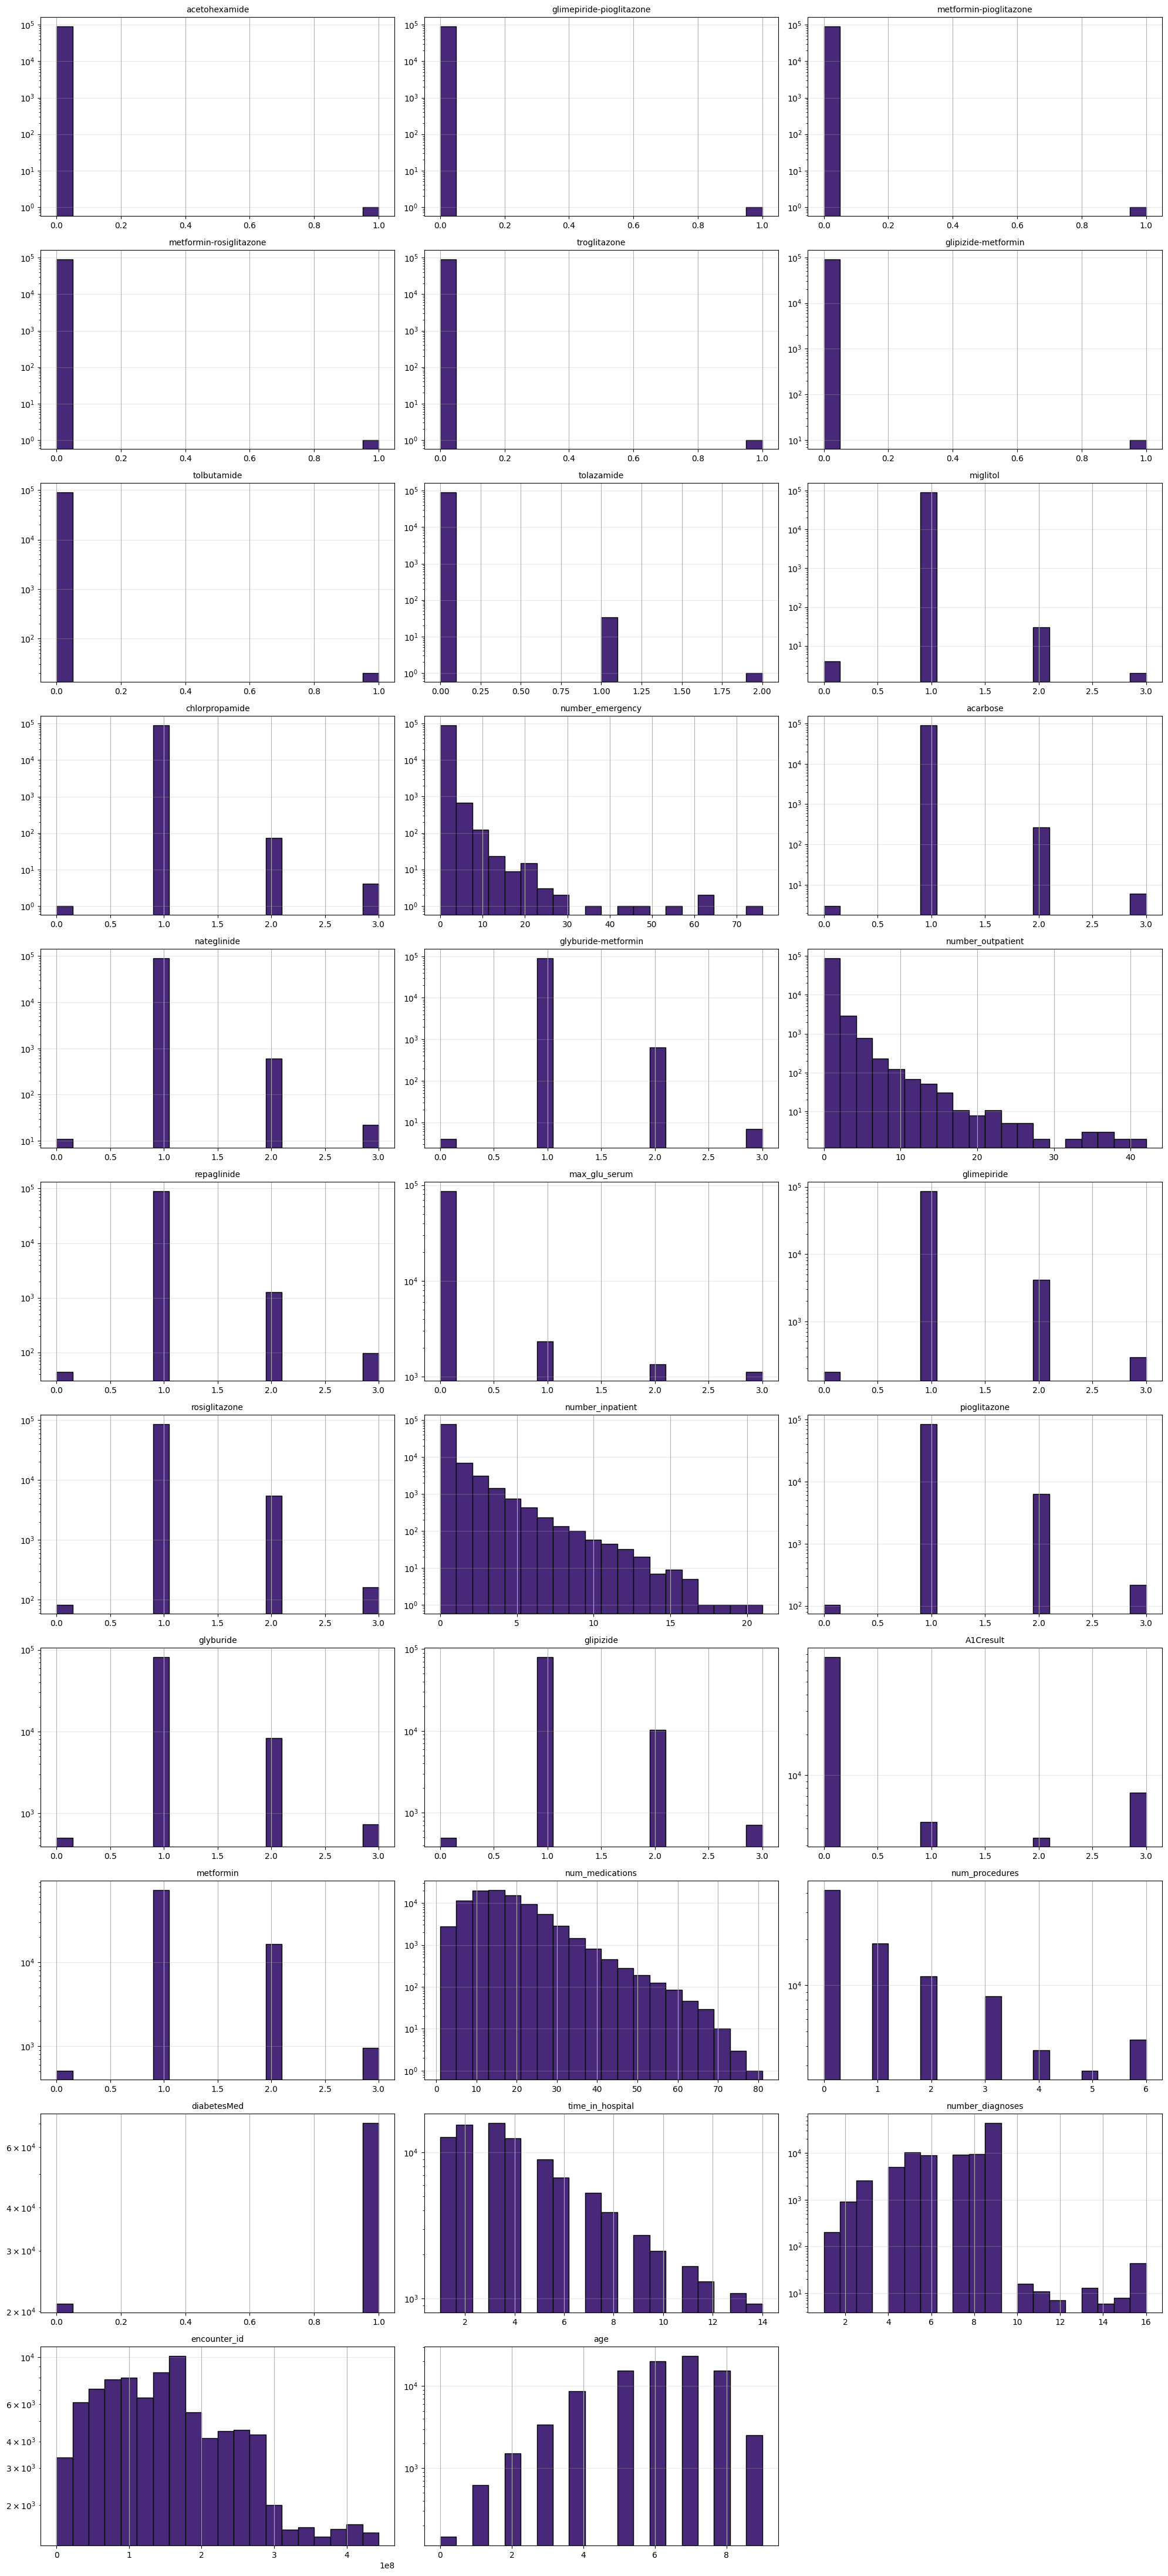

In [ ]:
"""
Visualize Skew in Data via Histogram
"""
num_features = len(non_encoded_skews)
num_cols = 3
num_rows = num_features // num_cols + 1

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 4))
axes = axes.flatten()

for i, (col, skew) in enumerate(non_encoded_skews):
    ax = axes[i]
    
    df_6[col].hist(ax=ax, color='#482878', edgecolor='black', bins=20)
    
    ax.set_yscale('log')
    
    ax.set_title(f"{col}", fontsize=10)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
"""
Log Transforms => Logistic Classifer
"""

'\nLog Transforms => Logistic Classifer\n'

In [ ]:
"""
Multicollinearity Test
"""

'\nMulticollinearity Test\n'

## End of Exploratory Data Analysis
---
## Start of Model Building

Drop useless columns

In [ ]:
print(df_6.columns)
df_7 = df_6.drop(['Unnamed: 0', 'encounter_id', 'patient_nbr'], axis = 1)

Index(['Unnamed: 0', 'encounter_id', 'patient_nbr', 'gender', 'age',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient',
       ...
       'admission_source_id_6.0', 'admission_source_id_7.0',
       'admission_source_id_8.0', 'admission_source_id_10.0',
       'admission_source_id_11.0', 'admission_source_id_13.0',
       'admission_source_id_14.0', 'admission_source_id_22.0',
       'admission_source_id_25.0', 'readmitted'],
      dtype='object', length=154)


### Decision Tree
Train a simple decision tree. Simply a benchmark to compare random forest or boosting to. 

In [ ]:
#imports
from sklearn import tree

In [ ]:
#First split into training and validation set
X_train, X_test, y_train, y_test = train_test_split(df_7.drop(['readmitted'], axis = 1), df_7.loc[:, "readmitted"], test_size=0.2)

In [ ]:
simple_tree = tree.DecisionTreeClassifier()
simple_tree.fit(X_train, y_train)

print("Test error: ", 1 - simple_tree.score(X_train, y_train))
print("Validation error: ", 1 - simple_tree.score(X_test, y_test))

Test error:  0.0
Validation error:  0.5250027295556283


See if different criterion leads to better models

In [ ]:
simple_tree = tree.DecisionTreeClassifier(criterion="entropy")
simple_tree.fit(X_train, y_train)

print("Test error: ", 1 - simple_tree.score(X_train, y_train))
print("Validation error: ", 1 - simple_tree.score(X_test, y_test))

Test error:  0.0
Validation error:  0.526476689594934


Try some regularization. See whats the best we can get with a single decision tree

Attempt to regularize with max depth, best is max depth = 6 (val error: 0.41). 

In [ ]:
short_tree = tree.DecisionTreeClassifier(max_depth = 6) #6 is best for some reason
short_tree.fit(X_train, y_train)

print("Test error: ", 1 - short_tree.score(X_train, y_train))
print("Validation error: ", 1 - short_tree.score(X_test, y_test))

Test error:  0.42173574811316894
Validation error:  0.4269570913855224


Text(0, 0.5, 'Error')

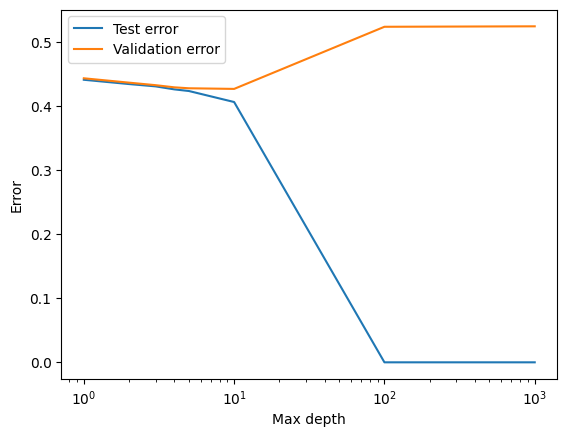

In [ ]:
heights = [1,2,3,4, 5, 10, 100, 1000]
test = []
val = []

for height in heights:
    short_tree = tree.DecisionTreeClassifier(max_depth = height) 
    short_tree.fit(X_train, y_train)

    test.append(1 - short_tree.score(X_train, y_train))
    val.append(1 - short_tree.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(heights, test, label = "Test error")
plt.plot(heights, val, label = "Validation error")
plt.legend()
plt.xlabel("Max depth")
plt.ylabel("Error")

Attempt to regularize with min samples, best is min_samples_split = 0.01 (val error: 0.41). 

In [ ]:
min_parent = tree.DecisionTreeClassifier(min_samples_split = 0.01) #0.01 is best for some reason
min_parent.fit(X_train, y_train)

print("Test error: ", 1 - min_parent.score(X_train, y_train))
print("Validation error: ", 1 - min_parent.score(X_test, y_test))

Test error:  0.40483956817840616
Validation error:  0.42613822469701934


Text(0, 0.5, 'Error')

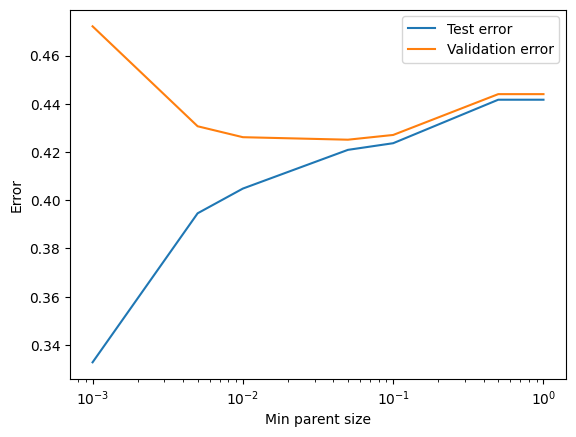

In [ ]:
heights = [1.0, .5, .1, 0.05, 0.01, 0.005, 0.001]
test = []
val = []

for height in heights:
    min_parent = tree.DecisionTreeClassifier(min_samples_split = height) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(heights, test, label = "Test error")
plt.plot(heights, val, label = "Validation error")
plt.legend()
plt.xlabel("Min parent size")
plt.ylabel("Error")

Attempt to regularize with maximum leaf nodes. Best is max_leaf_nodes = 250 (val error: 0.41). 

In [ ]:
min_parent = tree.DecisionTreeClassifier(max_leaf_nodes = 250)
min_parent.fit(X_train, y_train)

print("Test error: ", 1 - min_parent.score(X_train, y_train))
print("Validation error: ", 1 - min_parent.score(X_test, y_test))

Test error:  0.40606788497495594
Validation error:  0.42477344688284746


Text(0, 0.5, 'Error')

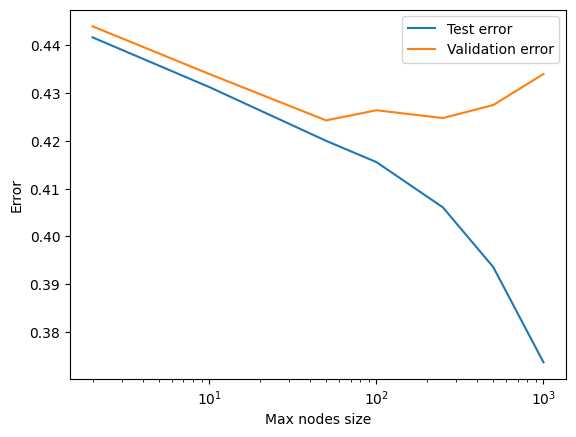

In [ ]:
nodes = [2, 10, 50, 100, 250, 500, 1000]
test = []
val = []

for node in nodes:
    min_parent = tree.DecisionTreeClassifier(max_leaf_nodes = node) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(nodes, test, label = "Test error")
plt.plot(nodes, val, label = "Validation error")
plt.legend()
plt.xlabel("Max nodes size")
plt.ylabel("Error")

It looks like the lowest validation error a single decison tree can achieve on this dataset is .41. 

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Default random forest

In [ ]:
default = RandomForestClassifier()
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.0
Validation error:  0.4140735888197401


Try different ways of max number of features checked.

In [ ]:
default = RandomForestClassifier(max_features="log2")
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.0
Validation error:  0.42018779342723


0.4152745932962114


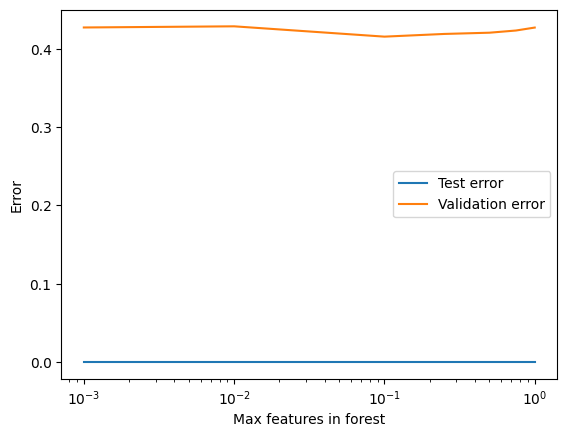

In [ ]:
trees = [0.001, 0.01, 0.1, 0.25, .5, .75, 1]
test = []
val = []

last_num = 0
for tree_num in trees:
    min_parent = RandomForestClassifier(max_features = tree_num, n_jobs=-1, warm_start=True) 
    min_parent.fit(X_train, y_train)

    last_num = tree_num

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(trees, test, label = "Test error")
plt.plot(trees, val, label = "Validation error")
plt.legend()
plt.xlabel("Max features in forest")
plt.ylabel("Error")
print(min(val))

Number of trees

0.41320013101867015


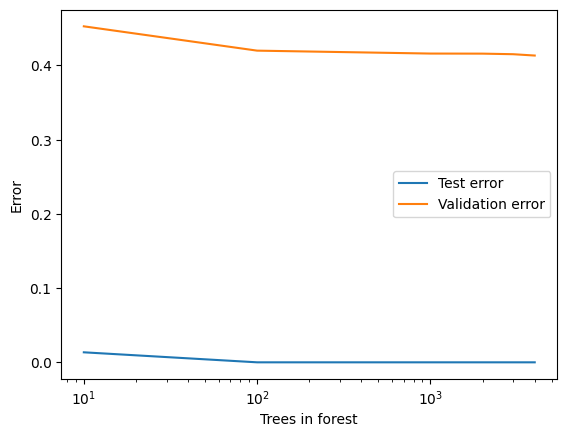

In [ ]:
trees = [10, 100, 1000, 2000, 3000, 4000]
test = []
val = []

last_num = 0
for tree_num in trees:
    min_parent = RandomForestClassifier(n_estimators = tree_num-last_num, n_jobs=-1, warm_start=True) 
    min_parent.fit(X_train, y_train)

    last_num = tree_num

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(trees, test, label = "Test error")
plt.plot(trees, val, label = "Validation error")
plt.legend()
plt.xlabel("Trees in forest")
plt.ylabel("Error")
print(min(val))

Experiment combine randomforest with maxleafnode

0.41620264220984826


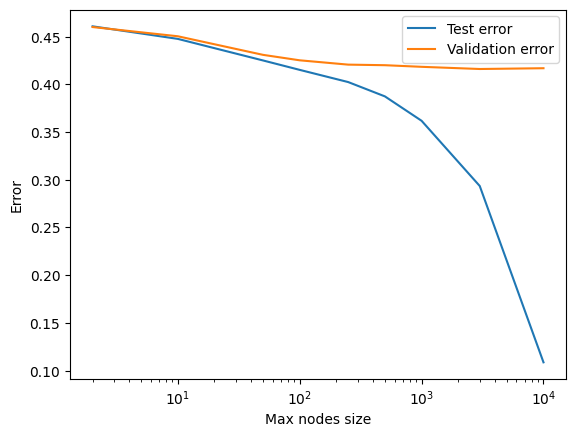

In [ ]:
nodes = [2, 10, 50, 100, 250, 500, 1000, 3000, 10000]
test = []
val = []

for node in nodes:
    min_parent = RandomForestClassifier(n_jobs=-1, max_leaf_nodes = node) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(nodes, test, label = "Test error")
plt.plot(nodes, val, label = "Validation error")
plt.legend()
plt.xlabel("Max nodes size")
plt.ylabel("Error")
print(min(val))

Max samples

In [ ]:
default = RandomForestClassifier(max_samples= .9, n_estimators = 2000, n_jobs=-1)
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.0
Validation error:  0.41560213997161266


0.4130363576809696


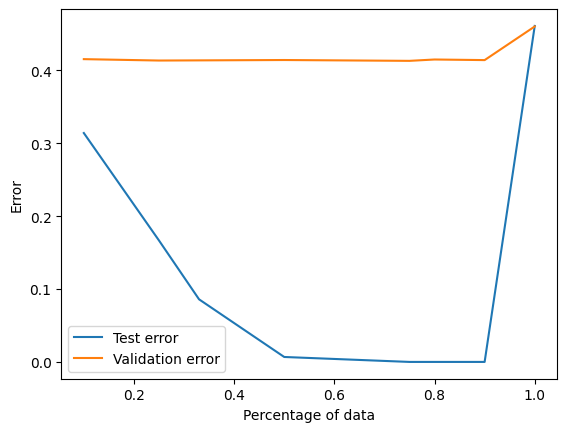

In [ ]:
sample = [.1, .25, .33, .5, .75, .8, .9, 1]
test = []
val = []

for sample_size in sample:
    min_parent = RandomForestClassifier(max_samples= sample_size, n_estimators = 2000, n_jobs=-1) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
#plt.xscale("log")
plt.plot(sample, test, label = "Test error")
plt.plot(sample, val, label = "Validation error")
plt.legend()
plt.xlabel("Percentage of data")
plt.ylabel("Error")
print(min(val))

Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
default = HistGradientBoostingClassifier()
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.3788811398779872
Validation error:  0.41063434872802707


Text(0, 0.5, 'Error')

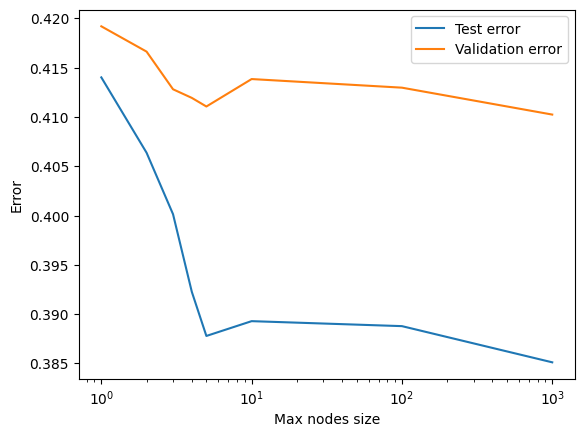

In [ ]:
heights = [1,2,3,4, 5, 10, 100, 1000]

test = []
val = []

for height in heights:
    min_parent = HistGradientBoostingClassifier(max_iter = 500, max_depth = height) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(heights, test, label = "Test error")
plt.plot(heights, val, label = "Validation error")
plt.legend()
plt.xlabel("Max nodes size")
plt.ylabel("Error")

Best boost results. 

In [ ]:
default = HistGradientBoostingClassifier(max_leaf_nodes=250, max_depth = 5)
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.3882163475317656
Validation error:  0.41210830876733273


0.41063434872802707


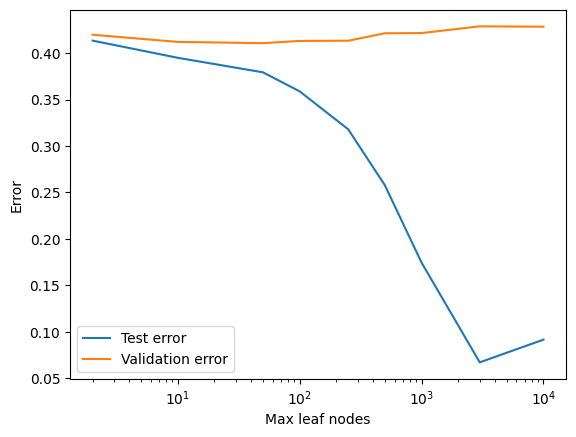

In [ ]:
nodes = [2, 10, 50, 100, 250, 500, 1000, 3000, 10000]
test = []
val = []

for node in nodes:
    min_parent = HistGradientBoostingClassifier(max_leaf_nodes = node, max_iter = 500) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(nodes, test, label = "Test error")
plt.plot(nodes, val, label = "Validation error")
plt.legend()
plt.xlabel("Max leaf nodes")
plt.ylabel("Error")
print(min(val))

Final models

In [80]:
df_test = pd.read_csv('testing_data.csv')

for col, miss_val in column_to_missing.items():
    df_test[col] = df_test[col].replace(miss_val, np.nan)
message = "True Missing Counts:"
df_test.isnull().sum()

for i in range(1,4):

    mask = df_test[f'diag_{i}'].str.contains('^[EV]', regex=True, na=False)
    mask_nan = df_test[f'diag_{i}'].isna()
    combined_mask = mask | mask_nan
    
    df_test.loc[~combined_mask, f'diag_{i}'] = df_test.loc[~combined_mask, f'diag_{i}'].apply(categorize_diag)
    df_test.loc[mask, f'diag_{i}'] = df_test.loc[mask, f'diag_{i}'].apply(convert_EV_code)

"""
Based on medical specialty => reduces total features

Applies to: `medical_specialty`
"""
df_test['medical_specialty'] = df_test['medical_specialty'].apply(map_specialty_to_group)

"""
Categorizing ambiguous mappings together.

For example, admission_source_id has categories 9, 15, 17, 20, and 21, which map to
Not availble, not availible, Null, not mapped, unknown

Group 9, 15, 17, 20 and 21 together to null. Reduces features & remove noise

Applies to `admission_type_id`, `discharge_disposition_id`, `admission_source_id`
"""
df_test['admission_type_id'] = df_test['admission_type_id'].apply(build_map_to_none([5, 6, 8]))
df_test['discharge_disposition_id'] = df_test['discharge_disposition_id'].apply(build_map_to_none([18, 25, 26]))
df_test['admission_source_id'] = df_test['admission_source_id'].apply(build_map_to_none([9, 15, 17, 20, 21]))

df_test.drop(columns=['weight', 'examide', 'citoglipton'], inplace=True)

mode_impute_col_names = ['race', 'payer_code', 'medical_specialty', 'gender', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

def mode_impute(df_column):
    mask = df_column.notna()
    mode = df_column[mask].mode()[0]
    updated_df_column = df_column.fillna(mode)
    return updated_df_column

for name in mode_impute_col_names:
    df_test[name] = mode_impute(df_test[name])

col_names = ['max_glu_serum', 'A1Cresult']

for name in col_names:
    df_test[name] = df_test[name].replace(np.nan, 'Unknown')

    df_test = df_5.copy()

# Ordinal Encoding
for col in ordinal_cols:
    ord_enc = OrdinalEncoder(categories=[mapping[col]])
    df_test[col] = ord_enc.fit_transform(df_test[[col]])

# Non-Ordinal, One-Hot Encoding
df_test = pd.get_dummies(df_test, columns=non_ordinal_cols, drop_first=True)

df_test['readmitted'] = np.select(
    [
        df_test['readmitted_NO'] == True,
        df_test['readmitted_>30'] == False
    ],
    [
        'NO',
        '>30'
    ],
    default='<30'
)

# Drop the extra columns created from encoding
df_test = df_test.drop(columns=["readmitted_NO", "readmitted_>30", 'Unnamed: 0', 'encounter_id', 'patient_nbr'])

X_test, y_test = (df_test.drop(['readmitted'], axis = 1), df_test.loc[:, "readmitted"])

In [81]:
default = tree.DecisionTreeClassifier(max_leaf_nodes = 250)
default.fit(X_train, y_train)

print("Test accuracy: ", default.score(X_train, y_train))
print("Validation accuracy: ", default.score(X_test, y_test))

Test accuracy:  0.5939321150250441
Validation accuracy:  0.5901909617967224


In [82]:
default = RandomForestClassifier(max_samples= .9, max_depth = 6)
default.fit(X_train, y_train)

print("Test accuracy: ", default.score(X_train, y_train))
print("Validation accuracy: ", default.score(X_test, y_test))

Test accuracy:  0.5597030202945231
Validation accuracy:  0.5586478725611154


In [83]:
default = HistGradientBoostingClassifier(max_leaf_nodes=250, max_depth = 5)
default.fit(X_train, y_train)

print("Test accuracy: ", default.score(X_train, y_train))
print("Validation accuracy: ", default.score(X_test, y_test))

Test accuracy:  0.6103096723123747
Validation accuracy:  0.6056950070423304
